# Test 5: Raw Map, Occupied-Area Removal, Adaptive Coarsening, and Representative Nodes

This notebook is intentionally minimal. It only does four things:
1. loads the raw Ukraine road network
2. removes the currently occupied area from the usable sovereign-held border region
3. computes adaptive coarsening with one real representative raw-road node per coarse node
4. shows those representative nodes on top of the filtered original road map


In [1]:
from pathlib import Path

import contextily as ctx
import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import osmnx as ox
import pandas as pd
from sklearn.cluster import DBSCAN

from synthetic_data.config import load_config
from synthetic_data.raw_graph import load_raw_graph
from synthetic_data.occupied import (
    annotate_graph_with_border_metrics,
    clip_graph_to_sovereign_border,
    load_current_occupied_snapshot,
    load_ukraine_sovereign_geometry,
)
from synthetic_data.demand import load_demand_nodes, snap_demand_nodes_to_graph

config = load_config()
ox.settings.log_console = True
pd.set_option("display.max_columns", 100)


In [2]:
# Load raw map, current occupied area, and the new sovereign-held border.

G_raw = load_raw_graph(config)
occupied = load_current_occupied_snapshot(config)
borders = load_ukraine_sovereign_geometry(config, occupied["occupied_geom"])

G_clipped, clip_debug = clip_graph_to_sovereign_border(
    G_raw,
    borders["sovereign_geom"],
    occupied["occupied_geom"],
    config,
)

G_filtered, filter_debug = annotate_graph_with_border_metrics(
    G_clipped,
    borders["sovereign_geom"],
    occupied["occupied_geom"],
    borders["sovereign_border_metric"],
    borders["frontline_boundary_metric"],
    borders["exterior_boundary_metric"],
    clip_debug,
    config,
)

acled_df, demand_raw, demand_medoid_indices = load_demand_nodes(config)
demand_snapped = snap_demand_nodes_to_graph(demand_raw, G_filtered)

print("Raw road graph:", G_raw.number_of_nodes(), "nodes /", G_raw.number_of_edges(), "edges")
print("Filtered road graph:", G_filtered.number_of_nodes(), "nodes /", G_filtered.number_of_edges(), "edges")
print("Removed outside new border:", len(filter_debug["removed_outside_new_border_nodes"]))
print("Demand centroids:", len(demand_raw), "-> snapped demand nodes:", len(demand_snapped))
print("Occupied snapshot date:", occupied["snapshot_date"])


Raw road graph: 25048 nodes / 49033 edges
Filtered road graph: 20244 nodes / 39254 edges
Removed outside new border: 4797
Demand centroids: 15 -> snapped demand nodes: 15
Occupied snapshot date: 2026-03-29 00:00:00


In [3]:
# Adaptive coarsening with one representative raw-road node per coarse node.
# Coarse edge travel_time and length_m are routed on the real filtered road graph
# between those representative raw nodes.

def adaptive_coarsen_graph_with_representatives(
    G,
    demand_points,
    eps_near,
    eps_mid,
    eps_far,
    near_radius,
    mid_radius,
):
    if hasattr(demand_points, "loc"):
        demand_coords = demand_points[["lat", "lon"]].to_numpy(dtype=float)
    else:
        demand_coords = np.asarray(demand_points, dtype=float)

    if len(demand_coords) == 0:
        raise ValueError("Need at least one demand point for adaptive coarsening")

    node_ids = list(G.nodes())
    coords = np.array([[G.nodes[n]["y"], G.nodes[n]["x"]] for n in node_ids], dtype=float)

    node_to_demand_dist = {}
    zone_to_nodes = {"near": [], "mid": [], "far": []}
    for i, n in enumerate(node_ids):
        dist = np.sqrt(((demand_coords - coords[i]) ** 2).sum(axis=1)).min()
        node_to_demand_dist[n] = float(dist)
        if dist <= near_radius:
            zone_to_nodes["near"].append(n)
        elif dist <= mid_radius:
            zone_to_nodes["mid"].append(n)
        else:
            zone_to_nodes["far"].append(n)

    zone_eps = {"near": eps_near, "mid": eps_mid, "far": eps_far}
    node_to_cluster = {}
    cluster_info = {}
    cluster_id = 0

    for zone in ["near", "mid", "far"]:
        zone_nodes = zone_to_nodes[zone]
        if not zone_nodes:
            continue

        zone_coords = np.array([[G.nodes[n]["y"], G.nodes[n]["x"]] for n in zone_nodes], dtype=float)
        labels = DBSCAN(eps=zone_eps[zone], min_samples=1).fit(zone_coords).labels_

        for label in sorted(set(labels)):
            members = [zone_nodes[i] for i, lab in enumerate(labels) if lab == label]
            cid = cluster_id
            cluster_id += 1

            for n in members:
                node_to_cluster[n] = cid

            centroid_lat = float(np.mean([G.nodes[n]["y"] for n in members]))
            centroid_lon = float(np.mean([G.nodes[n]["x"] for n in members]))
            rep_node = min(
                members,
                key=lambda n: (G.nodes[n]["y"] - centroid_lat) ** 2 + (G.nodes[n]["x"] - centroid_lon) ** 2,
            )

            cluster_info[cid] = {
                "zone": zone,
                "lat": float(G.nodes[rep_node]["y"]),
                "lon": float(G.nodes[rep_node]["x"]),
                "centroid_lat": centroid_lat,
                "centroid_lon": centroid_lon,
                "rep_node": rep_node,
                "member_count": len(members),
                "mean_demand_dist": float(np.mean([node_to_demand_dist[n] for n in members])),
            }

    coarse = nx.Graph()
    for cid, attrs in cluster_info.items():
        coarse.add_node(cid, **attrs)

    routing_graph = ox.convert.to_undirected(G)

    def routed_path_metrics(graph, source, target):
        path = nx.shortest_path(graph, source, target, weight="travel_time")
        total_time = 0.0
        total_length = 0.0
        for a, b in zip(path[:-1], path[1:]):
            edge_bundle = graph.get_edge_data(a, b)
            if edge_bundle is None:
                raise nx.NetworkXNoPath(f"Missing edge data for segment {(a, b)}")

            if isinstance(edge_bundle, dict) and all(isinstance(k, int) for k in edge_bundle.keys()):
                candidates = list(edge_bundle.values())
            else:
                candidates = [edge_bundle]

            finite = [d for d in candidates if np.isfinite(d.get("travel_time", np.nan)) and np.isfinite(d.get("length", np.nan))]
            best = min(finite if finite else candidates, key=lambda d: float(d.get("travel_time", np.inf)))
            total_time += float(best.get("travel_time", np.nan))
            total_length += float(best.get("length", np.nan))
        return float(total_time), float(total_length)

    edge_aggregates = {}
    for u, v, data in G.edges(data=True):
        cu = node_to_cluster.get(u)
        cv = node_to_cluster.get(v)
        if cu is None or cv is None or cu == cv:
            continue
        key = tuple(sorted((cu, cv)))
        agg = edge_aggregates.setdefault(key, {"count": 0})
        agg["count"] += 1

    for (cu, cv), agg in edge_aggregates.items():
        rep_u = cluster_info[cu]["rep_node"]
        rep_v = cluster_info[cv]["rep_node"]
        try:
            rep_travel_time, rep_length_m = routed_path_metrics(routing_graph, rep_u, rep_v)
        except (nx.NetworkXNoPath, nx.NodeNotFound, ValueError):
            continue

        coarse.add_edge(
            cu,
            cv,
            travel_time=rep_travel_time,
            length_m=rep_length_m,
            abstracted_path_count=agg["count"],
        )

    coarse = coarse.subgraph(max(nx.connected_components(coarse), key=len)).copy()
    surviving = set(coarse.nodes())
    node_to_cluster = {n: cid for n, cid in node_to_cluster.items() if cid in surviving}
    return coarse, node_to_cluster, zone_to_nodes

adaptive_params = config["adaptive_coarsening"]
CG_rep, raw_node_to_cluster, raw_zone_membership = adaptive_coarsen_graph_with_representatives(
    G_filtered,
    demand_snapped[["lat", "lon"]],
    eps_near=float(adaptive_params["eps_near"]),
    eps_mid=float(adaptive_params["eps_mid"]),
    eps_far=float(adaptive_params["eps_far"]),
    near_radius=float(adaptive_params["near_radius"]),
    mid_radius=float(adaptive_params["mid_radius"]),
)

rep_nodes_df = pd.DataFrame([
    {
        "coarse_node": cid,
        "rep_node": data["rep_node"],
        "zone": data["zone"],
        "member_count": data["member_count"],
        "lat": data["lat"],
        "lon": data["lon"],
        "centroid_lat": data["centroid_lat"],
        "centroid_lon": data["centroid_lon"],
    }
    for cid, data in CG_rep.nodes(data=True)
]).sort_values("coarse_node").reset_index(drop=True)

print("Adaptive coarse graph:", CG_rep.number_of_nodes(), "nodes /", CG_rep.number_of_edges(), "edges")
print("Representative nodes per zone:")
print(rep_nodes_df["zone"].value_counts().to_dict())
display(rep_nodes_df.head(12))


Adaptive coarse graph: 106 nodes / 185 edges
Representative nodes per zone:
{'near': 59, 'mid': 41, 'far': 6}


,coarse_node,rep_node,zone,member_count,lat,lon,centroid_lat,centroid_lon
0,0,628666381,near,315,46.673281,32.586294,46.688701,32.601620
1,1,343640524,near,1,47.431325,33.868001,47.431325,33.868001
2,3,883299983,near,6,46.628105,31.558678,46.628448,31.545328
3,4,7912310084,near,74,46.625397,30.834090,46.624746,30.876984
4,5,1188892762,near,9,47.070367,32.792367,47.067431,32.789399
5,8,4590547515,near,6,47.068261,33.627809,47.067872,33.626932
6,9,12484906865,near,1,46.928825,31.615751,46.928825,31.615751
7,10,12485067206,near,1,46.780812,31.346403,46.780812,31.346403
8,11,1637488961,near,1,47.539280,33.669039,47.539280,33.669039
9,12,2356071456,near,2,51.909397,31.648070,51.867419,31.625920


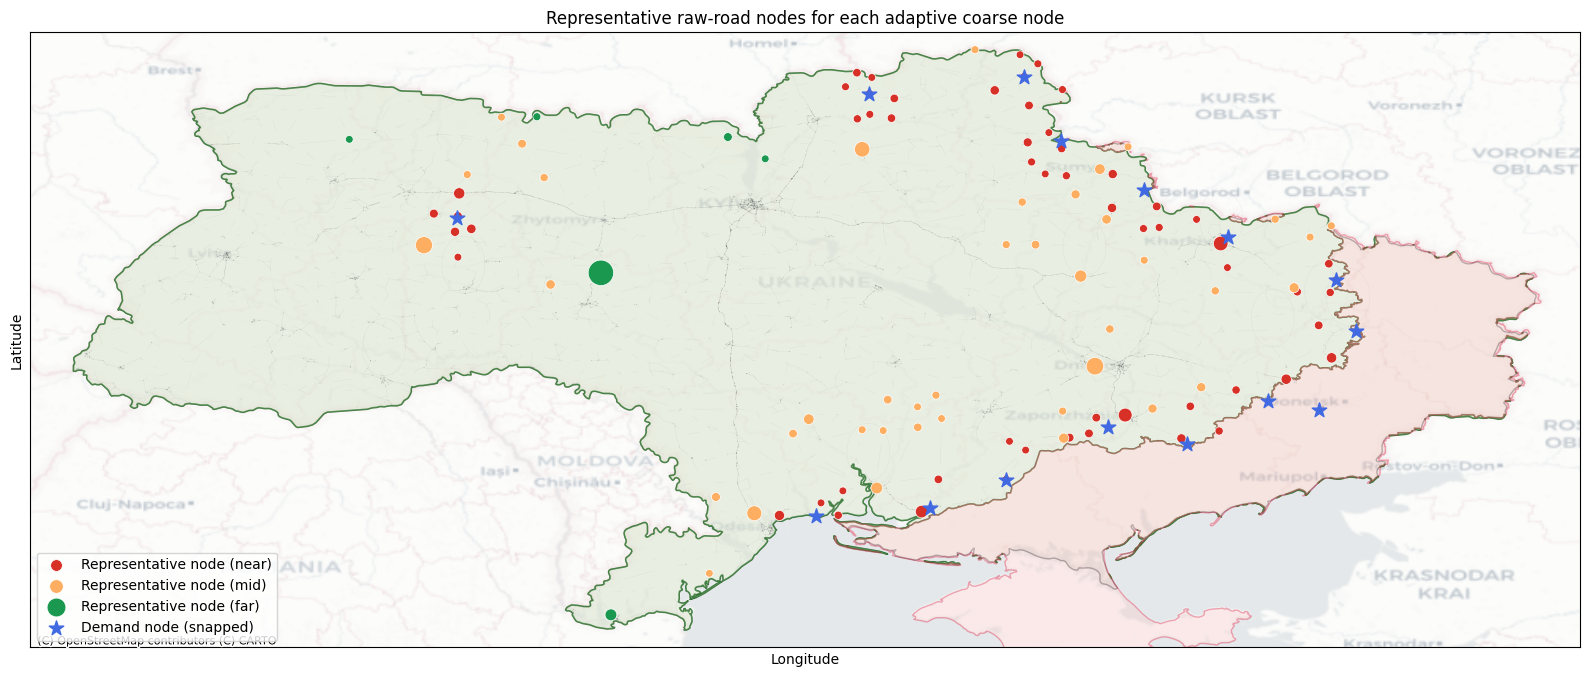

In [4]:
# Show representative nodes on top of the filtered original road map.

zone_colors = {"near": "#d73027", "mid": "#fdae61", "far": "#1a9850"}
plot_graph = ox.convert.to_undirected(G_filtered)
if plot_graph.number_of_nodes() > 0:
    plot_graph = plot_graph.subgraph(max(nx.connected_components(plot_graph), key=len)).copy()
road_pos = {n: (d["x"], d["y"]) for n, d in plot_graph.nodes(data=True)}

fig, ax = plt.subplots(figsize=(16, 10))
borders["ukraine_shape"].plot(ax=ax, facecolor="#f2ecdf", edgecolor="black", linewidth=1.0, alpha=0.95, zorder=0)
borders["sovereign_shape"].plot(ax=ax, facecolor="#dfead9", edgecolor="darkgreen", linewidth=1.2, alpha=0.55, zorder=0.2)
occupied["occupied_gs"].plot(ax=ax, color="#f7c8c8", edgecolor="crimson", linewidth=1.0, alpha=0.35, zorder=0.3)

nx.draw_networkx_edges(plot_graph, road_pos, ax=ax, edge_color="gray", alpha=0.10, width=0.35)

for zone in ["near", "mid", "far"]:
    zone_df = rep_nodes_df[rep_nodes_df["zone"] == zone]
    if len(zone_df) == 0:
        continue
    ax.scatter(
        zone_df["lon"],
        zone_df["lat"],
        c=zone_colors[zone],
        s=28 + 3 * np.sqrt(zone_df["member_count"]),
        edgecolors="white",
        linewidths=0.5,
        zorder=4,
        label=f"Representative node ({zone})",
    )

ax.scatter(
    demand_snapped["lon"],
    demand_snapped["lat"],
    marker="*",
    c="royalblue",
    s=120,
    zorder=5,
    label="Demand node (snapped)",
)

minx, miny, maxx, maxy = borders["ukraine_shape"].total_bounds
x_pad = (maxx - minx) * 0.03
y_pad = (maxy - miny) * 0.03
ax.set_xlim(minx - x_pad, maxx + x_pad)
ax.set_ylim(miny - y_pad, maxy + y_pad)

try:
    ctx.add_basemap(ax, crs="EPSG:4326", source=ctx.providers.CartoDB.Positron, zoom=6, alpha=0.6)
except Exception as exc:
    print(f"Basemap unavailable, continuing without tiles: {exc}")

ax.set_title("Representative raw-road nodes for each adaptive coarse node")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal", adjustable="box")
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()
